Data for Manuscript

In [4]:
import os
import glob
import re
import csv
import warnings
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Any

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 
import cv2
from scipy.ndimage import rotate as ndimage_rotate
from scipy.signal import butter, filtfilt, savgol_filter, savgol_filter

# Suppress specific warnings
warnings.simplefilter('ignore', np.RankWarning)
warnings.simplefilter('ignore', RuntimeWarning)

# =========================================================
#               GLOBAL CONFIGURATION (KNOBS)
# =========================================================

# --- Hardware/Output Knobs ---
PIXEL_SIZE_UM = globals().get('PIXEL_SIZE_UM', 0.3069) # um per pixel
SAVE_DIR = Path(globals().get('SAVE_DIR', r"D:\out")) # set None to disable saving
PLOT_FIG = globals().get('PLOT_FIG', True)
SAVE_TO_INPUT_DIR = globals().get('SAVE_TO_INPUT_DIR', True)
SAVE_IN_SUBFOLDER = globals().get('SAVE_IN_SUBFOLDER', True)
PRINT_SAVE_LOG = globals().get('PRINT_SAVE_LOG', True)
_LAST_INPUT_PATH : Optional[Path] = None

# --- Geometric Correction Knobs (Rotation/Crop) ---
AUTO_ROTATE = globals().get('AUTO_ROTATE', True)
FINAL_ORIENTATION = globals().get('FINAL_ORIENTATION', "landscape") # "landscape", "portrait", or None
AUTO_CROP = globals().get('AUTO_CROP', True)
CROP_MARGIN_UM = globals().get('CROP_MARGIN_UM', 0.0)

# Rotation Estimator Knobs
EPS_FOOTPRINT = 0.0
CENTRAL_BAND = (0.10, 0.90)
MIN_COLS_USED = 40
MIN_RUN_PX = 8
SMOOTH_WIN = 21
MAD_THR = 3.5
ROTATE_PASSES = 2
GRAD_KEEP_PCT = 70

# --- Defect Mask Processing Knobs ---
BLUR_KSIZE = globals().get('BLUR_KSIZE', 0)
MORPH_KERNEL_PX = globals().get('MORPH_KERNEL_PX', 4)
MORPH_ITERS = globals().get('MORPH_ITERS', 1)

# --- Morphology (Fatten Blobs) Knobs ---
FATTEN_BLOBS = globals().get('FATTEN_BLOBS', True)
KERNEL_SIZE_PX = globals().get('KERNEL_SIZE_PX', 4)
DILATE_ITERS = globals().get('DILATE_ITERS', 2)
ERODE_ITERS = globals().get('ERODE_ITERS', 1)
BINARIZE_FROM = globals().get('BINARIZE_FROM', "dilated")

# =========================================================
#               PART 1: HELPER FUNCTIONS
# =========================================================

def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def _load_matrix(p: Path, delimiter=",") -> np.ndarray:
    """Loads matrix from a file path."""
    return np.loadtxt(p, delimiter=delimiter, dtype=float)

def extract_number(text: str) -> Optional[int]:
    match = re.search(r'(\d+)', os.path.basename(text))
    if match:
        return int(match.group(1))
    return None

def _outdir_for_current_file() -> Path:
    """Compute output directory based on the currently loaded input path."""
    if _LAST_INPUT_PATH is None:
        return Path(SAVE_DIR or ".")
    base = _LAST_INPUT_PATH.parent if SAVE_TO_INPUT_DIR else Path(SAVE_DIR or ".")
    return (base / _LAST_INPUT_PATH.stem) if SAVE_IN_SUBFOLDER else base

def _mad(x: np.ndarray) -> Tuple[float, float]:
    """Computes Median and Median Absolute Deviation (MAD)."""
    x = x[~np.isnan(x)]
    if x.size == 0: return 0.0, 1.0
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return med, mad if mad > 1e-9 else 1.0

def _sg_smooth(y: np.ndarray, win: int = SMOOTH_WIN) -> np.ndarray:
    """Applies Savitzky-Golay filter or returns original if disabled/unsuitable."""
    if win and win >= 5 and (win % 2 == 1) and y.size >= win:
        try:
            return savgol_filter(y, win, 2)
        except:
            return y
    return y

def _rotate(img: np.ndarray, angle_deg: float, *, is_mask: bool = False) -> np.ndarray:
    """Rotates an image/mask using OpenCV."""
    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle_deg, 1.0)
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    border_val = 0 if is_mask else 0
    return cv2.warpAffine(img, M, (w, h), flags=interp,
                          borderMode=cv2.BORDER_CONSTANT, borderValue=border_val)

def center_crop_512(grid: np.ndarray) -> np.ndarray:
    """Crops or pads the grid to an exact 512x512 size, centered."""
    h, w = grid.shape
    ph = max(0, 512 - h) // 2
    pw = max(0, 512 - w) // 2
    if ph > 0 or pw > 0:
        grid = np.pad(grid, ((ph, ph), (pw, pw)), mode='constant', constant_values=0.0)
        h, w = grid.shape
    cy, cx = h // 2, w // 2
    # Ensure exact 512x512 crop
    return grid[cy - 256:cy + 256 + (h % 2), cx - 256:cx + 256 + (w % 2)][:512, :512]


# =========================================================
#             PART 2: ROTATION & MASK UTILS
# =========================================================

def _footprint_mask(matrix: np.ndarray, eps: float = EPS_FOOTPRINT) -> np.ndarray:
    """Generates a mask of the non-zero region and keeps the largest connected component."""
    m0 = (np.abs(matrix) > eps).astype(np.uint8)
    H, W = m0.shape
    k_size = max(5, int(round(0.03 * min(H, W))))
    if k_size % 2 == 0: k_size += 1
    kernel = np.ones((k_size, k_size), np.uint8)
    m = cv2.morphologyEx(m0, cv2.MORPH_CLOSE, kernel, iterations=1)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if num <= 1:
        return m
    lcc_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == lcc_idx).astype(np.uint8)

def _rotation_from_top_bottom_robust(mask_fp: np.ndarray) -> float:
    """Estimates rotation from the linear fit of the top and bottom edges of the footprint."""
    H, W = mask_fp.shape
    top = np.full(W, np.nan)
    bot = np.full(W, np.nan)
    for x in range(W):
        ys = np.flatnonzero(mask_fp[:, x])
        if ys.size >= MIN_RUN_PX:
            top[x], bot[x] = ys[0], ys[-1]
            
    lo = int(np.floor(CENTRAL_BAND[0] * W))
    hi = int(np.ceil(CENTRAL_BAND[1] * W))
    xs = np.arange(W, dtype=float)[lo:hi]
    top_band, bot_band = top[lo:hi], bot[lo:hi]
    good = ~np.isnan(top_band) & ~np.isnan(bot_band)
    xs, top_band, bot_band = xs[good], top_band[good], bot_band[good]
    if xs.size < MIN_COLS_USED: return 0.0
    
    width = bot_band - top_band
    w_med, w_mad = _mad(width)
    keep_w = np.abs(width - w_med) <= MAD_THR * w_mad
    xs, top_band, bot_band = xs[keep_w], top_band[keep_w], bot_band[keep_w]
    if xs.size < MIN_COLS_USED: return 0.0
    
    top_s = _sg_smooth(top_band); bot_s = _sg_smooth(bot_band)
    
    def fit_robust(x, y):
        # This is a robust fit, but not the RANSAC style implemented below
        a, b = np.polyfit(x, y, 1)
        resid = y - (a * x + b)
        _, mad = _mad(resid)
        m = np.abs(resid) <= MAD_THR * mad
        if m.sum() >= max(10, int(0.5 * y.size)):
            a, b = np.polyfit(x[m], y[m], 1)
        return a
    
    aT = fit_robust(xs, top_s)
    aB = fit_robust(xs, bot_s)
    rotT = float(-np.degrees(np.arctan(aT)))
    rotB = float(-np.degrees(np.arctan(aB)))
    return float((rotT + rotB) / 2.0)

def _dominant_stripe_rotation_ccw(matrix: np.ndarray, fp_mask: np.ndarray) -> float:
    """Estimates rotation based on the dominant orientation of the image gradient (stripe direction)."""
    m = matrix.astype(np.float32)
    gx = cv2.Sobel(m, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(m, cv2.CV_32F, 0, 1, ksize=3)
    fp = (fp_mask > 0)
    if not np.any(fp): return 0.0
    gx, gy = gx[fp], gy[fp]
    mag = np.sqrt(gx * gx + gy * gy)
    if mag.size < 100: return 0.0
    
    kth = np.percentile(mag, GRAD_KEEP_PCT)
    sel = mag >= kth
    gx, gy = gx[sel], gy[sel]
    if gx.size < 100: return 0.0
    
    Sxx = float(np.sum(gx * gx))
    Syy = float(np.sum(gy * gy))
    Sxy = float(np.sum(gx * gy))
    if (Sxx + Syy) <= 0: return 0.0
    
    phi = 0.5 * np.arctan2(2.0 * Sxy, (Sxx - Syy))
    stripe_dir = phi + np.pi / 2.0
    rot_ccw_deg = float(-np.degrees(stripe_dir))
    rot_ccw_deg = (rot_ccw_deg + 90) % 180 - 90
    return rot_ccw_deg

def _enforce_orientation(matrix: np.ndarray, mask: np.ndarray, orientation: Optional[str]):
    """Rotates the image/mask 90 degrees if the footprint aspect ratio doesn't match the target orientation."""
    if orientation is None: return matrix, mask
    fp = _footprint_mask(matrix)
    if not np.any(fp): return matrix, mask
    ys, xs = np.nonzero(fp)
    h = ys.max() - ys.min() + 1
    w = xs.max() - xs.min() + 1
    orientation = orientation.lower()
    need_rotation = (orientation == "landscape" and h > w) or \
                    (orientation == "portrait" and w > h)
    if need_rotation:
        return np.rot90(matrix, -1), np.rot90(mask, -1) # Rotated clockwise by 90
    return matrix, mask

def _crop_to_footprint(matrix: np.ndarray, mask: Optional[np.ndarray] = None) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """Crops the matrix and mask to the bounding box of non-zero elements, plus a margin."""
    fp = (matrix != 0)
    ys, xs = np.nonzero(fp)
    if ys.size == 0: return matrix, mask
    y0, y1 = ys.min(), ys.max() + 1
    x0, x1 = xs.min(), xs.max() + 1
    mpx = max(0, int(round(CROP_MARGIN_UM / PIXEL_SIZE_UM)))
    y0 = max(0, y0 - mpx); y1 = min(matrix.shape[0], y1 + mpx)
    x0 = max(0, x0 - mpx); x1 = min(matrix.shape[1], x1 + mpx)
    matrix_c = matrix[y0:y1, x0:x1]
    mask_c   = mask[y0:y1, x0:x1] if mask is not None else None
    return matrix_c, mask_c

def _morph_fatten(mask_uint8: np.ndarray) -> Tuple[np.ndarray, Dict[str, Any]]:
    """Custom morphology to 'fatten' the blobs (Dilate then Erode) and binarize."""
    k = np.ones((KERNEL_SIZE_PX, KERNEL_SIZE_PX), np.uint8)
    dil = cv2.dilate(mask_uint8, k, iterations=DILATE_ITERS)
    ero = cv2.erode(dil, k, iterations=ERODE_ITERS) if ERODE_ITERS > 0 else dil
    cls = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, k, iterations=1)
    pick = BINARIZE_FROM.lower()
    src = {"dilated": dil, "eroded_final": ero, "closed": cls}.get(pick, dil)
    proc = (src > 0.5).astype(np.uint8)
    dbg = {"dilated": dil, "eroded": ero, "closed": cls, "picked": pick}
    return proc, dbg

# =========================================================
#            PART 3: CIRCLE MINIMA & HISTOGRAM
# =========================================================

def _save_circle_min_and_histogram(csv_path: Path, hist_path: Path):
    """Reads per-circle values, calculates minima, saves new CSV, and plots histogram."""
    def log(msg):
        if PRINT_SAVE_LOG: print(msg)
        
    if not csv_path.exists():
        log(f"[hist] SKIP: circle-values CSV not found -> {csv_path.name}")
        return
    try:
        df = pd.read_csv(csv_path)
    except Exception as e:
        log(f"[hist] SKIP: failed to read CSV ({e}) -> {csv_path.name}")
        return
    if "values_list" not in df.columns:
        log(f"[hist] SKIP: 'values_list' column missing in {csv_path.name}")
        return
    min_values = []
    for row in df["values_list"]:
        if isinstance(row, str) and row.strip():
            try:
                vals = [float(v) for v in row.split(";") if v.strip()]
                if vals: min_values.append(min(vals))
            except ValueError: continue
    if not min_values:
        log(f"[hist] SKIP: no per-circle values parsed in {csv_path.name}")
        return
    
    # Save per-circle minima CSV
    min_csv = csv_path.parent / (csv_path.stem.replace("_circle_values", "_circle_minima") + ".csv")
    pd.DataFrame({
        "circle_id": np.arange(1, len(min_values) + 1),
        "min_value_um": min_values
    }).to_csv(min_csv, index=False)
    
    # Save histogram
    try:
        plt.figure(figsize=(7, 5))
        plt.hist(min_values, bins="auto", edgecolor="black")
        plt.xlabel("Most negative value per circle [µm]")
        plt.ylabel("Frequency")
        plt.title("Histogram of per-circle minima")
        plt.tight_layout()
        plt.savefig(hist_path, dpi=200)
        plt.close()
        log(f"[hist] OK: wrote {min_csv.name} and {hist_path.name}")
    except Exception as e:
        log(f"[hist] SKIP: plotting failed ({e}) for {hist_path.name}")


# =========================================================
#            PART 4: PLOTTING & SAMPLING
# =========================================================

def _overlay_plot(matrix: np.ndarray, centers_um: List[Tuple[float, float]],
                 diameters_um: List[float], title: str, save_path: Optional[Path] = None, 
                 show: bool = True, c_min: Optional[float] = None, c_max: Optional[float] = None, 
                 cmap_name: str = "magma"): # 💡 Added cmap_name for flexibility
    """
    Plots the matrix with detected circles overlaid.
    Accepts optional c_min and c_max to manually set the colorbar limits.
    """
    H, W = matrix.shape
    extent = [0, W * PIXEL_SIZE_UM, H * PIXEL_SIZE_UM, 0]
    
    # --- Color Map Limits Logic ---
    if c_min is not None and c_max is not None:
        vmin, vmax = c_min, c_max
    else:
        # Use robust percentile calculation if custom limits are not provided
        nz = matrix[matrix != 0]
        vmin, vmax = (np.percentile(nz, [1, 99]) if nz.size else (None, None))
    
    plt.figure(figsize=(7, 7))
    im = plt.imshow(matrix, extent=extent, cmap=cmap_name,
                    vmin=vmin, vmax=vmax, interpolation="nearest")
    ax = plt.gca()
    for (cx, cy), d in zip(centers_um, diameters_um):
        ax.add_patch(plt.Circle((cx, cy), d / 2.0, fill=False, linewidth=1.8, color="k"))
    plt.title(title)
    cbar = plt.colorbar(im); cbar.set_label("Deflection [µm]")
    plt.xlabel("x [µm]"); plt.ylabel("y [µm]")
    plt.tight_layout()
    if save_path:
        _ensure_dir(save_path.parent)
        plt.savefig(save_path, dpi=200)
    if show: plt.show()
    plt.close()

def _plot_3d_surface(grid: np.ndarray, save_path: Optional[Path] = None, show: bool = True, cmap_name: str = "magma"):
    """Generates and displays a static 3D surface plot."""
    H, W = grid.shape
    x = np.arange(W) * PIXEL_SIZE_UM
    y = np.arange(H) * PIXEL_SIZE_UM
    X, Y = np.meshgrid(x, y)
    Z = grid
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the surface
    surf = ax.plot_surface(X, Y, Z, cmap=cmap_name, linewidth=0, antialiased=False)
    
    # Customize the plot
    ax.set_xlabel('X Position [µm]')
    ax.set_ylabel('Y Position [µm]')
    ax.set_zlabel('Detrended Y Position [pixels]') 
    ax.set_title("3D Reconstructed Surface Map")
    
    # Add a color bar
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Z Value (Detrended Y)')
    
    plt.tight_layout()
    if save_path:
        _ensure_dir(save_path.parent)
        plt.savefig(save_path, dpi=200)
    if show:
        plt.show()
    plt.close()

def _sample_values_in_circles_simple(matrix: np.ndarray, centers_um: List[Tuple[float, float]], diameters_um: List[float]) -> List[Dict[str, Any]]:
    """Extracts all pixel values within each detected circle."""
    vals_list = []
    r_um_to_px = 0.5 / PIXEL_SIZE_UM
    h, w = matrix.shape
    for (cx_um, cy_um), d_um in zip(centers_um, diameters_um):
        cx, cy = cx_um / PIXEL_SIZE_UM, cy_um / PIXEL_SIZE_UM
        r = d_um * r_um_to_px
        x0, x1 = max(0, int(cx - r)), min(w, int(cx + r) + 1)
        y0, y1 = max(0, int(cy - r)), min(h, int(cy + r) + 1)
        if x1 <= x0 or y1 <= y0:
            vals = np.array([], dtype=float)
        else:
            yy, xx = np.ogrid[y0:y1, x0:x1]
            m = (xx - cx)**2 + (yy - cy)**2 <= r**2
            vals = matrix[y0:y1, x0:x1][m].astype(float)
        vals_list.append({
            "center_um": (float(cx_um), float(cy_um)),
            "diameter_um": float(d_um),
            "values": vals
        })
    return vals_list

# =========================================================
#            PART 5: MAIN PIPELINE (MASK PROCESSING)
# =========================================================

def _apply_rotation_pass(matrix: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Performs one coarse (top/bottom) and one fine (gradient) rotation correction step."""
    # Coarse: Top/Bottom Robust Fit
    fp = _footprint_mask(matrix)
    rot_coarse = _rotation_from_top_bottom_robust(fp)
    if abs(rot_coarse) > 1e-6:
        matrix = _rotate(matrix, rot_coarse, is_mask=False)
        mask   = _rotate(mask,   rot_coarse, is_mask=True)
    
    # Fine: Dominant Stripe Gradient
    fp = _footprint_mask(matrix)
    rot_fine = _dominant_stripe_rotation_ccw(matrix, fp)
    if abs(rot_fine) > 1e-6:
        matrix = _rotate(matrix, rot_fine, is_mask=False)
        mask   = _rotate(mask,   rot_fine, is_mask=True)
        
    return matrix, mask

def create_mask_from_matrix(path: Path, threshold: float, *, delimiter: str = ",") -> Tuple[np.ndarray, np.ndarray]:
    """
    Loads matrix, creates initial mask, applies auto-rotation, orientation, and cropping.
    Returns (mask, matrix).
    """
    global _LAST_INPUT_PATH
    p = Path(path); _LAST_INPUT_PATH = p
    matrix = _load_matrix(p, delimiter=delimiter)
    # Initial mask: points below the threshold
    mask = (matrix < float(threshold)).astype(np.uint8)
    
    if AUTO_ROTATE:
        for i in range(ROTATE_PASSES):
            matrix, mask = _apply_rotation_pass(matrix, mask)
            
    # Force final orientation
    matrix, mask = _enforce_orientation(matrix, mask, FINAL_ORIENTATION)
    
    # Auto-crop to non-zero footprint
    if AUTO_CROP:
        matrix, mask = _crop_to_footprint(matrix, mask)
        
    return mask, matrix

def process_mask_core_um(
    *,
    mask: np.ndarray,
    matrix: np.ndarray,
    pixel_size_um: float = PIXEL_SIZE_UM,
    min_size_um: float = 5.0,
    max_size_um: float = 500.0,
    blur_ksize: int = BLUR_KSIZE,
    morph_kernel_px: int = MORPH_KERNEL_PX,
    morph_iters: int = MORPH_ITERS,
) -> Dict[str, Any]:
    # --- Morphology ---
    if FATTEN_BLOBS:
        proc, _dbg = _morph_fatten(mask)
    else:
        proc = mask.copy()
        if blur_ksize and blur_ksize >= 3 and blur_ksize % 2 == 1:
            proc = cv2.GaussianBlur(proc, (blur_ksize, blur_ksize), 0)
        k = np.ones((morph_kernel_px, morph_kernel_px), np.uint8)
        proc = cv2.morphologyEx(proc, cv2.MORPH_CLOSE, k, iterations=morph_iters)
        proc = (proc > 0).astype(np.uint8)
    
    # --- Connected Component Analysis ---
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(proc, connectivity=8, ltype=cv2.CV_32S)
    min_px = max(1, int(round(min_size_um / pixel_size_um)))
    max_px = max(1, int(round(max_size_um / pixel_size_um)))
    H, W = matrix.shape
    centers_um, diam_um = [], []
    kept_mask = np.zeros_like(proc, dtype=np.uint8)
    kept = 0
    
    # Filter components by bounding box size (stats[lab][cv2.CC_STAT_WIDTH/HEIGHT])
    for lab in range(1, num_labels):
        x, y, w, h, area = stats[lab] 
        s = max(w, h)
        if min_px <= s <= max_px:
            kept += 1
            comp = (labels == lab)
            kept_mask[comp] = 1
            cx, cy = centroids[lab]
            centers_um.append((float(cx) * pixel_size_um, float(cy) * pixel_size_um))
            diam_um.append(float(s) * pixel_size_um)
    
    # Global matrix statistics
    nz = matrix[matrix != 0]
    total_avg_um = float(np.mean(nz)) if nz.size else float(np.mean(matrix))
    total_std_um = float(np.std(nz)) if nz.size else float(np.std(matrix))
    
    return {
        "matrix_shape": (H, W),
        "num_before_filter": int(num_labels - 1),
        "num_after_filter": int(kept),
        "element_centers_um": centers_um,
        "element_diameters_um": diam_um,
        "processed_mask": proc,
        "kept_mask": kept_mask,
        "total_avg_um": total_avg_um,
        "total_std_um": total_std_um,
    }

def process_mask(mask: np.ndarray, matrix: np.ndarray, *, min_size: float = 5, max_size: float = 100,
                 cmap_min: Optional[float] = None, cmap_max: Optional[float] = None, cmap_name: str = "magma"):
    """Orchestrates the mask processing, defect filtering, plotting, and saving."""
    results = process_mask_core_um(
        mask=mask, matrix=matrix, min_size_um=float(min_size), max_size_um=float(max_size))
    
    infile = _LAST_INPUT_PATH
    stem = (infile.stem if infile else "matrix")
    
    # Pass limits and name to overlay plots
    plot_kwargs = {'c_min': cmap_min, 'c_max': cmap_max, 'cmap_name': cmap_name} 
    
    if SAVE_DIR is not None or SAVE_TO_INPUT_DIR:
        outdir = _outdir_for_current_file()
        _ensure_dir(outdir)
        
        np.savetxt(outdir / f"{stem}_corrected.txt", matrix, delimiter=",", fmt="%.6g")
        np.save   (outdir / f"{stem}_corrected.npy", matrix)
        cv2.imwrite(str(outdir / f"{stem}_kept_mask.png"),
                    (results["kept_mask"] * 255).astype(np.uint8))
        
        # Elements CSV (omitted for brevity, assume unchanged)
        with open(outdir / f"{stem}_elements.csv", "w", newline="") as f:
             w = csv.writer(f)
             w.writerow(["circle_id","center_x_um","center_y_um","diameter_um"])
             for i, ((cx, cy), d) in enumerate(zip(results["element_centers_um"], results["element_diameters_um"]), 1):
                 w.writerow([i, f"{cx:.6g}", f"{cy:.6g}", f"{d:.6g}"])
        
        # Circle Values CSV (omitted for brevity, assume unchanged)
        circle_values_csv = outdir / f"{stem}_circle_values.csv"
        with open(circle_values_csv, "w", newline="") as f:
             w = csv.writer(f)
             w.writerow(["circle_id","center_x_um","center_y_um","diameter_um","n","mean_um","std_um","min_um","max_um","values_list"])
             vals_list = _sample_values_in_circles_simple(matrix, results["element_centers_um"], results["element_diameters_um"])
             for i, item in enumerate(vals_list, 1):
                 vals = item["values"]; n = int(vals.size)
                 mean = float(np.mean(vals)) if n else float("nan")
                 std  = float(np.std(vals))  if n else float("nan")
                 vmin = float(np.min(vals))  if n else float("nan")
                 vmax = float(np.max(vals))  if n else float("nan")
                 vstr = ";".join(f"{v:.6g}" for v in vals.tolist())
                 cx_um, cy_um = item["center_um"]; d_um = item["diameter_um"]
                 w.writerow([i, f"{cx_um:.6g}", f"{cy_um:.6g}", f"{d_um:.6g}",
                             n, f"{mean:.6g}", f"{std:.6g}", f"{vmin:.6g}", f"{vmax:.6g}", vstr])
        
        # Minima + Histogram (omitted for brevity, assume unchanged)
        hist_path = outdir / f"{stem}_circle_minima_hist.png"
        _save_circle_min_and_histogram(circle_values_csv, hist_path)
        
        # Overlay plot (Saved to file)
        _overlay_plot(matrix, results["element_centers_um"], results["element_diameters_um"],
                      title=(infile.name if infile else "Defect Count") + " — corrected",
                      save_path=outdir / f"{stem}_overlay.png", show=False, **plot_kwargs) 
    
    # Inline plot (Displayed)
    if PLOT_FIG:
        title = (_LAST_INPUT_PATH.name if _LAST_INPUT_PATH else "Defect Count")
        _overlay_plot(matrix, results["element_centers_um"], results["element_diameters_um"],
                      title=title, save_path=None, show=True, **plot_kwargs) 
        
    print("Process mask complete.")



In [5]:
import os
import glob
import re
import csv
import warnings
from pathlib import Path
from typing import Optional, Tuple, List, Dict, Any

# Third-party libraries
import numpy as np
import pandas as pd
import cv2
from scipy.signal import butter, filtfilt, savgol_filter

# --- NEW IMPORT FOR INTERACTIVITY ---
import plotly.graph_objects as go

# Suppress specific warnings
warnings.simplefilter('ignore', np.RankWarning)
warnings.simplefilter('ignore', RuntimeWarning)

# ... (Include all previous Global Configs and Helper Functions here) ...
# ... (Include Parts 1, 2, 3, 4, 5 from previous code here) ...
# To save space, I will focus on the modified Part 6 below.

# =========================================================
#            PART 6: 3D RECONSTRUCTION (INTERACTIVE)
# =========================================================

def robust_poly_fit(x: np.ndarray, y: np.ndarray, degree: int = 2, threshold: float = 3.0, max_iter: int = 1000) -> np.ndarray:
    """Fits a polynomial using RANSAC-like outlier rejection."""
    n = len(x)
    if n <= degree + 1:
        safe_degree = max(0, n - 1)
        try: return np.polyval(np.polyfit(x, y, safe_degree), x)
        except: return y

    best_inliers = None
    best_inlier_count = 0
    
    for _ in range(max_iter):
        try:
            sample_idxs = np.random.choice(n, degree + 1, replace=False)
            coeffs = np.polyfit(x[sample_idxs], y[sample_idxs], degree)
            y_pred = np.polyval(coeffs, x)
            inliers = np.abs(y - y_pred) < threshold
            count = np.sum(inliers)
            if count > best_inlier_count:
                best_inlier_count = count
                best_inliers = inliers
        except: continue

    try:
        if best_inliers is not None and np.sum(best_inliers) > degree+1:
            final_coeffs = np.polyfit(x[best_inliers], y[best_inliers], degree)
        else:
            final_coeffs = np.polyfit(x, y, degree)
        return np.polyval(final_coeffs, x)
    except: return y

def analyzer_3d(file_path: Path, **kwargs) -> Optional[Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """Analyzes a single 2D matrix file."""
    try: loaded_matrix = np.loadtxt(file_path, delimiter=',')
    except: return None
    loaded_matrix = loaded_matrix[50:-50, 50:-50]
    rows, cols = loaded_matrix.shape
    if rows > cols:
        extra = (rows - cols) // 2
        loaded_matrix = loaded_matrix[extra:extra + cols, :]
    elif cols > rows:
        extra = (cols - rows) // 2
        loaded_matrix = loaded_matrix[:, extra:extra + rows]
    
    y_coords, x_coords = np.where(loaded_matrix != 0)
    if len(x_coords) < 3: return None
    order = np.argsort(x_coords)
    x_coords = x_coords[order]; y_coords = y_coords[order]
    
    y_fitted = robust_poly_fit(x_coords, y_coords, degree=2, threshold=4.0)
    dif = y_coords - y_fitted
    
    cutoff = 0.25
    b, a = butter(2, cutoff, btype='low')
    padlen = 3 * (max(len(a), len(b)) - 1)
    if len(dif) <= padlen: y_filtered = dif.copy()
    elif len(dif) < 3 * padlen:
        win = min(len(dif) // 2 * 2 + 1, 7)
        y_filtered = savgol_filter(dif, win, 2)
    else:
        try: y_filtered = filtfilt(b, a, dif)
        except: y_filtered = dif.copy()
    
    return x_coords, y_coords, y_filtered

def _plot_3d_interactive(grid: np.ndarray, save_path: Optional[Path] = None, show: bool = True, 
                         colorscale: str = 'Viridis', c_min=None, c_max=None):
    """
    Generates an INTERACTIVE 3D Surface plot using Plotly.
    Allows rotation, zoom, and panning.
    """
    H, W = grid.shape
    # Create coordinate grid
    x = np.arange(W) * PIXEL_SIZE_UM
    y = np.arange(H) * PIXEL_SIZE_UM
    
    # Define layout scene with aspect ratio preserved
    layout = go.Layout(
        title='Interactive 3D Surface Map',
        width=800,
        height=800,
        scene=dict(
            xaxis_title='X [µm]',
            yaxis_title='Y [µm]',
            zaxis_title='Detrended Y',
            aspectmode='data' # This ensures 1 unit in X = 1 unit in Y = 1 unit in Z
        )
    )

    # Create the surface object
    surface = go.Surface(
        z=grid,
        x=x,
        y=y,
        colorscale=colorscale,
        cmin=c_min,
        cmax=c_max,
        colorbar=dict(title='Height')
    )

    fig = go.Figure(data=[surface], layout=layout)

    # Save as HTML (interactive file you can email/share)
    if save_path:
        html_path = save_path.with_suffix('.html')
        fig.write_html(str(html_path))
        print(f"Interactive 3D map saved to: {html_path.name}")
        # Still save a static PNG snapshot for quick preview
        # fig.write_image(str(save_path)) 

    if show:
        fig.show()

def Three_D(folder_path: str, cmap_name='Viridis', c_min=None, c_max=None, **kwargs) -> Optional[np.ndarray]:
    folder_path = Path(folder_path)
    txt_files = list(folder_path.glob('*.txt'))
    try: txt_files.sort(key=lambda x: int(re.search(r'(\d+)', x.name).group(1)) if re.search(r'(\d+)', x.name) else 0)
    except: txt_files.sort()
        
    strr = []
    print(f"Processing {len(txt_files)} files in {folder_path.name} for 3D reconstruction...")
    for file_path in txt_files:
        if "_3d_" in file_path.name: continue
        result = analyzer_3d(file_path, **kwargs)
        if result is not None: strr.append(result)
            
    if not strr: return None

    try:
        all_x = np.concatenate([data[0] for data in strr])
        all_y = np.concatenate([data[1] for data in strr])
        xmax = int(np.max(all_x))
        ymax = int(np.max(all_y))
    except: return None

    grid = np.full((ymax + 1, xmax + 1), 0.0)
    for data in strr:
        x, y, z = data 
        x = np.asarray(x, dtype=int); y = np.asarray(y, dtype=int)
        for xi, yi, zi in zip(x, y, z):
            if 0 <= yi < grid.shape[0] and 0 <= xi < grid.shape[1]:
                grid[yi, xi] = zi
    
    # Pad to 512
    h, w = grid.shape
    ph = max(0, 512 - h) // 2; pw = max(0, 512 - w) // 2
    if ph > 0 or pw > 0: grid = np.pad(grid, ((ph, ph), (pw, pw)), mode='constant')
    h, w = grid.shape
    cy, cx = h // 2, w // 2
    grid = grid[cy - 256:cy + 256 + (h % 2), cx - 256:cx + 256 + (w % 2)][:512, :512]

    output_path = folder_path / '3d_NO_ROTATION.txt'
    np.savetxt(output_path, grid, fmt='%f', delimiter=',')
    
    # --- INTERACTIVE 3D VISUALIZATION ---
    if PLOT_FIG:
        plot_path = folder_path / '3d_NO_ROTATION.png'
        # Map matplotlib cmap names to Plotly equivalents roughly
        plotly_cmap = 'RdBu' if cmap_name in ['coolwarm', 'bwr', 'seismic'] else 'Viridis'
        
        _plot_3d_interactive(grid, save_path=plot_path, show=True, 
                             colorscale=plotly_cmap, c_min=c_min, c_max=c_max)
    
    return grid

Polystyrene:

[hist] OK: wrote CL_2_3d_circle_minima.csv and CL_2_3d_circle_minima_hist.png


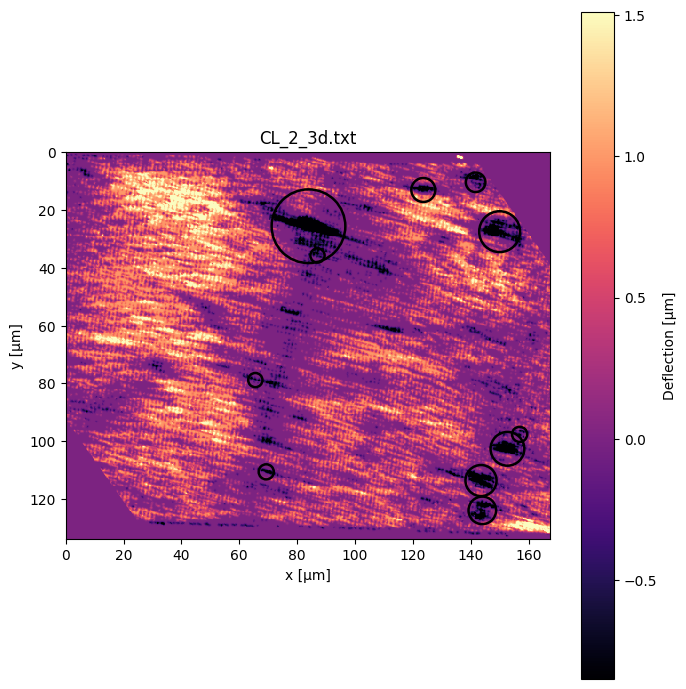

Process mask complete.
[hist] OK: wrote CL_2_3d_circle_minima.csv and CL_2_3d_circle_minima_hist.png


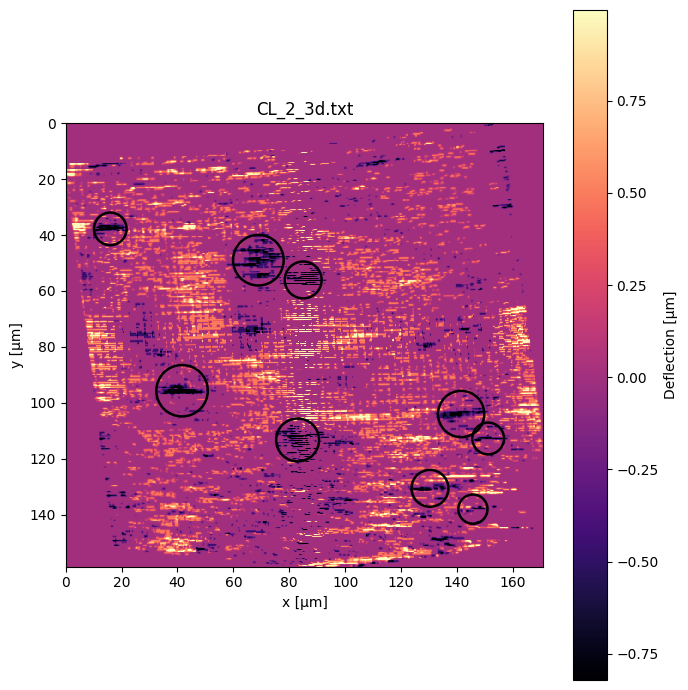

Process mask complete.
[hist] OK: wrote RCL_1_3d_circle_minima.csv and RCL_1_3d_circle_minima_hist.png


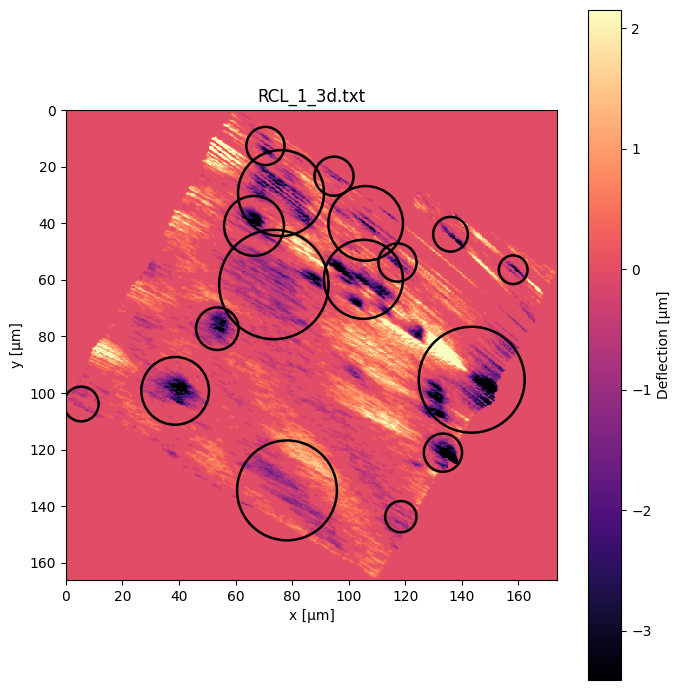

Process mask complete.
[hist] OK: wrote 60xw-38ul--Drop 1(4)_3d_circle_minima.csv and 60xw-38ul--Drop 1(4)_3d_circle_minima_hist.png


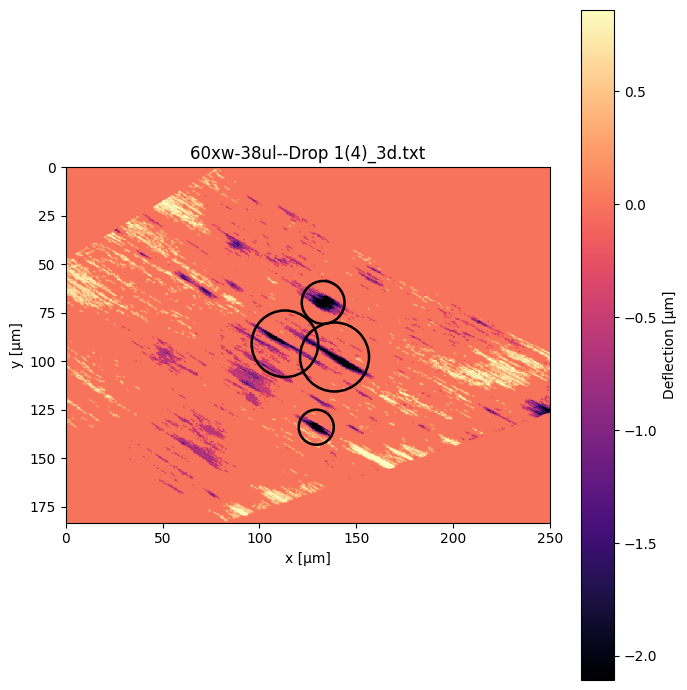

Process mask complete.
[hist] OK: wrote 60xw-38ul-Drop 1_3d_circle_minima.csv and 60xw-38ul-Drop 1_3d_circle_minima_hist.png


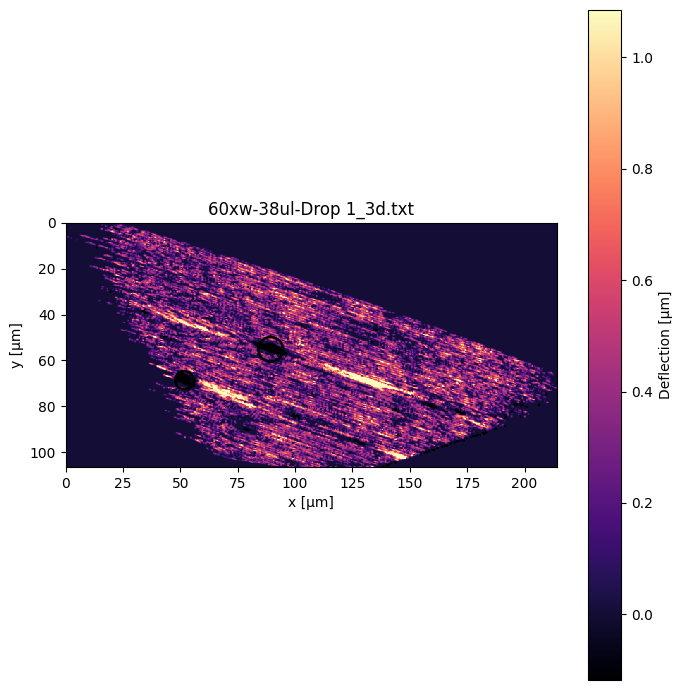

Process mask complete.


In [3]:
folder_path = r'D:\Lea\240618_PS\60x\Bottoms_view\Analysis\Test1\CL_2_3d.txt'
threshold = -1# Set your threshold value here

# Create the mask
mask, original_matrix = create_mask_from_matrix(folder_path, threshold)

# Process the mask and count the elements
process_mask(mask, original_matrix, min_size=5,max_size=100)
folder_path = r'D:\Lea\240616_PS\60x\bottom_view\Analysis\Test1\CL_2_3d.txt'
threshold = -1# Set your threshold value here

# Create the mask
mask, original_matrix = create_mask_from_matrix(folder_path, threshold)

# Process the mask and count the elements
process_mask(mask, original_matrix, min_size=10,max_size=100)
folder_path = r'D:\Lea\240623_PS\60x\bv\Analysis\Test1\RCL_1_3d.txt'
threshold = -1# Set your threshold value here

# Create the mask
mask, original_matrix = create_mask_from_matrix(folder_path, threshold)

# Process the mask and count the elements
process_mask(mask, original_matrix, min_size=10,max_size=100)
#FEW pinning eliminated... To close to the edge... artifacts


folder_path = r'D:\Diego\OLDDataSelection\20220911\Test1\60xw-38ul--Drop 1(4)_3d.txt'
threshold = -1# Set your threshold value here

# Create the mask
mask, original_matrix = create_mask_from_matrix(folder_path, threshold)

# Process the mask and count the elements
process_mask(mask, original_matrix, min_size=15,max_size=100)
folder_path = r'D:\Diego\OLDDataSelection\20220911\Test1\60xw-38ul-Drop 1_3d.txt'
threshold = -1# Set your threshold value here

# Create the mask
mask, original_matrix = create_mask_from_matrix(folder_path, threshold)

# Process the mask and count the elements
process_mask(mask, original_matrix, min_size=5,max_size=100)